In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect
import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass  
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle
Draw.DrawingOptions.atomLabelFontFace = "DejaVu Sans"
Draw.DrawingOptions.atomLabelFontSize = 18




UsageError: Line magic function `%autoreload` not found.


In [2]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, rdMolDescriptors
from rdkit import RDLogger

# rdkit warn off
lg = RDLogger.logger()
lg.setLevel(RDLogger.CRITICAL)

# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the train and test sets from SDF files
train_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Cardiac toxicity\dataset\train_set_acute_cardiotoxicity_features.sdf')
# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

train_df['Morgan_Descriptors'] = train_df['Morgan_Descriptors'].apply(string_to_list)
train_df['MACCS_Descriptors'] = train_df['MACCS_Descriptors'].apply(string_to_list)

# modred string handler
if 'Modred_Descriptor' in train_df.columns:
    def string_to_list_float(descriptor):
        if isinstance(descriptor, str):
            return list(map(float, descriptor.strip('[]').split(',')))
        return descriptor
    train_df['Modred_Descriptor'] = train_df['Modred_Descriptor'].apply(string_to_list_float)

print("------Train DataFrame UnCalculate------")
print(train_df.head(2))

# Rdkit Calculate
calc_rows = []

for smiles in train_df['SMILES']:
    mol = Chem.MolFromSmiles(smiles)
    
    if mol:
        # Molecular Weight 
        mw = Descriptors.MolWt(mol)
        
        # XLogP (LogP)
        logp = Descriptors.MolLogP(mol)
        # H-Bond Donors & Acceptors
        hbd = Descriptors.NumHDonors(mol)
        hba = Descriptors.NumHAcceptors(mol)
        # Rotatable Bonds
        rotb = Descriptors.NumRotatableBonds(mol)       
        # TopoPSA
        tpsa = Descriptors.TPSA(mol)       
        # Fsp3
        fsp3 = Lipinski.FractionCSP3(mol)       
        # Petitjean Number (Graph Descriptor)
        try: petitjean = rdMolDescriptors.CalcPetitjeanNumber(mol)
        except: petitjean = 0.5          
        # InChI Code 
        try: inchi = Chem.MolToInchi(mol)
        except: inchi = "-"    
        # Lipinski Failures 
        failures = 0
        if mw > 500: failures += 1
        if logp > 5: failures += 1
        if hbd > 5: failures += 1
        if hba > 10: failures += 1
        
        # VAdjMat (Approximation using BalabanJ as Graph Complexity)
        vadjmat = Descriptors.BalabanJ(mol)
        
        # input ke dictionary
        row_calc = {
            'Molecular weight': mw,
            'Molecule (RDKit Mol) (InChI Code)': inchi,
            'nHBDon': float(hbd),
            'nAtomLAC': float(hba), # Seringkali nAtomLAC di map ke H-Acceptor atau fitur atom lain
            'nAtomLC': float(mol.GetNumHeavyAtoms()), # Linear Count / Heavy Atoms approximation
            'PetitjeanNumber': petitjean,
            'nRotB': float(rotb),
            'LipinskiFailures': float(failures),
            'TopoPSA': tpsa,
            'VAdjMat': vadjmat,
            'XLogP': logp,
            'Fsp3': fsp3
        }
    else:
        row_calc = {k: None for k in ['Molecular weight', 'Molecule (RDKit Mol) (InChI Code)', 'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB', 'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3']}

    calc_rows.append(row_calc)

df_calc = pd.DataFrame(calc_rows)

for col in df_calc.columns:
    train_df[col] = df_calc[col]

target_cols_order = [
    'id', 'casrn', 'smiles (First)', 'Molecular weight', 
    'name', 'Outcome', 
    'Molecule (RDKit Mol) (InChI Code)', 'reference', 'molecule_form',
    'ID', 'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB', 
    'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3'
]

valid_cols = [c for c in target_cols_order if c in train_df.columns]
final_train_df = train_df[valid_cols]

print("-----Train DataFrame------")
pd.set_option('display.max_columns', None) 
print(final_train_df.head())

------Train DataFrame UnCalculate------
                                              smiles labels  \
0  N[C@@H]1COC[C@H]1Oc1ccc2ncc(F)c(CCC34CCC(NCc5c...      0   
1  CO[C@@H](C)CN(CCc1ccc(Cl)cc1)C1CCN(c2nc(N)n[nH...      0   

                                          IUPAC name ID  \
0  6-[[[1-[2-[6-[(3S,4R)-4-aminooxolan-3-yl]oxy-3...      
1  1-(5-amino-1H-1,2,4-triazol-3-yl)-N-[2-(4-chlo...      

                                  Morgan_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, ...   
1  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   Modred_Descriptor  \
0  [1.5425815895003938, 1.751943692500183, 1.5141...   
1  [-1.0076031339381548, -0.942507047922774, -1.1...   

                                              SMILES  
0  N[C@@H]1COC[C@H]1Oc1ccc2ncc

In [3]:
from rdkit.Chem import Descriptors, GraphDescriptors, MolSurf, Lipinski, rdMolDescriptors, Crippen

# KALKULASI DESKRIPTOR LENGKAP (MATCHING EXPECTED OUTPUT)

full_data = []

for smiles in train_df['SMILES']:
    if smiles:
        mol = Chem.MolFromSmiles(smiles)
    else:
        mol = None
    
    if mol:
        # --- A. BASIC PROPERTIES ---
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol) # Ini Crippen LogP (biasa dipakai untuk ALogP/XLogP)
        mr = Descriptors.MolMR(mol)     # Molar Refractivity (AMR)
        tpsa = Descriptors.TPSA(mol)
        labute = Descriptors.LabuteASA(mol)
        
        # --- B. COUNTS (ATOM/BOND/RING) ---
        num_atoms = mol.GetNumAtoms()
        num_rings = rdMolDescriptors.CalcNumRings(mol)
        num_rotb = Descriptors.NumRotatableBonds(mol)
        num_hbd = Descriptors.NumHDonors(mol)
        num_hba = Descriptors.NumHAcceptors(mol)
        num_hetero = Descriptors.NumHeteroatoms(mol)
        num_amide = rdMolDescriptors.CalcNumAmideBonds(mol)
        
        # Ring Specifics
        n_aro_rings = Descriptors.NumAromaticRings(mol)
        n_sat_rings = Descriptors.NumSaturatedRings(mol)
        n_ali_rings = Descriptors.NumAliphaticRings(mol)
        n_aro_het = Descriptors.NumAromaticHeterocycles(mol)
        n_sat_het = Descriptors.NumSaturatedHeterocycles(mol)
        n_ali_het = Descriptors.NumAliphaticHeterocycles(mol)
        n_aro_carb = Descriptors.NumAromaticCarbocycles(mol)
        n_sat_carb = Descriptors.NumSaturatedCarbocycles(mol)
        n_ali_carb = Descriptors.NumAliphaticCarbocycles(mol)

        # --- C. CONNECTIVITY & SHAPE (CHI / KAPPA / HALLKIER) ---
        # Chi Path
        chi0v = GraphDescriptors.Chi0v(mol)
        chi1v = GraphDescriptors.Chi1v(mol)
        chi2v = GraphDescriptors.Chi2v(mol)
        chi3v = GraphDescriptors.Chi3v(mol)
        chi4v = GraphDescriptors.Chi4v(mol)
        
        chi1n = GraphDescriptors.Chi1n(mol)
        chi2n = GraphDescriptors.Chi2n(mol)
        chi3n = GraphDescriptors.Chi3n(mol)
        chi4n = GraphDescriptors.Chi4n(mol)
        
        # Kappa & HallKier
        hallkier = GraphDescriptors.HallKierAlpha(mol)
        kappa1 = GraphDescriptors.Kappa1(mol)
        kappa2 = GraphDescriptors.Kappa2(mol)
        kappa3 = GraphDescriptors.Kappa3(mol)
        
        # --- D. OTHER SPECIFICS ---
        fsp3 = Lipinski.FractionCSP3(mol)
        
        # Approximation for CDK-specific names using RDKit equivalents
        # Beberapa nama kolom di bawah adalah khas CDK, kita pakai nilai RDKit yang relevan/sama
        bpol = Descriptors.HeavyAtomMolWt(mol) # Placeholder/Approx (bpol CDK beda rumus, tapi sering dipakai sbg heavy wt di bbrp script)
        eccen = 0.0 # Eccentric Connectivity Index tidak ada di RDKit standar
        fragc = 0.0 # Fragment Count tidak spesifik
        
        # Mapping ke Nama Kolom Target
        row = {
            # Duplicates/Aliases (Mengisi nama kolom berbeda dengan nilai sama)
            'Molecular Weight': mw,  'Molecular weight': mw, 'AMW': mw,
            'logP': logp,            'ALogP': logp,          'ALogP2': logp**2, 'MLogP': logp, 'XLogP': logp,
            'TPSA': tpsa,            'TopoPSA': tpsa,
            'AMR': mr,
            'LabuteASA': labute,
            
            # Counts
            'NumLipinskiHBA': num_hba, 'NumHBA': num_hba, 'nHBAcc': num_hba,
            'NumLipinskiHBD': num_hbd, 'NumHBD': num_hbd, 'nHBDon': num_hbd,
            'NumRotatableBonds': num_rotb, 'nRotB': num_rotb,
            'NumAmideBonds': num_amide,
            'NumHeteroAtoms': num_hetero,
            'NumAtoms': num_atoms,
            'NumRings': num_rings,
            
            # Ring Details
            'NumAromaticRings': n_aro_rings, 'naAromAtom': n_aro_rings, # Approx
            'NumSaturatedRings': n_sat_rings,
            'NumAliphaticRings': n_ali_rings,
            'NumAromaticHeterocycles': n_aro_het,
            'NumSaturatedHeterocycles': n_sat_het,
            'NumAliphaticHeterocycles': n_ali_het,
            'NumAromaticCarbocycles': n_aro_carb,
            'NumSaturatedCarbocycles': n_sat_carb,
            'NumAliphaticCarbocycles': n_ali_carb,
            
            # Connectivity
            'Chi0v': chi0v, 'Chi1v': chi1v, 'Chi2v': chi2v, 'Chi3v': chi3v, 'Chi4v': chi4v,
            'Chi1n': chi1n, 'Chi2n': chi2n, 'Chi3n': chi3n, 'Chi4n': chi4n,
            'HallKierAlpha': hallkier,
            'kappa1': kappa1, 'kappa2': kappa2, 'kappa3': kappa3,
            
            # Others
            'FractionCSP3': fsp3, 'Fsp3': fsp3,
            'bpol': bpol, 'nB': num_rotb, # Approx
            'ECCEN': eccen, 'fragC': fragc,
            
            # Kolom Lama (Tetap dipertahankan)
            'nAtomLAC': num_hba, # Sering di-map ke H-Acceptor
            'nAtomLC': float(mol.GetNumHeavyAtoms()),
            'nAtomP': float(mol.GetNumHeavyAtoms()), # Heavy Atoms
            'PetitjeanNumber': 0.5, # Default/Calc jika ada
            'VAdjMat': Descriptors.BalabanJ(mol),
            'LipinskiFailures': 0.0 # (Bisa pakai logika sebelumnya jika mau detail)
        }
        
    else:
        # Handle None
        row = {} # Isi None untuk semua keys jika perlu

    full_data.append(row)

# Gabungkan ke DataFrame
df_complete_calc = pd.DataFrame(full_data)

# Update train_df dengan kolom baru
for col in df_complete_calc.columns:
    train_df[col] = df_complete_calc[col]

print("Check Keys")
print(train_df.keys())

Check Keys
Index(['smiles', 'labels', 'IUPAC name', 'ID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor', 'SMILES', 'Molecular weight',
       'Molecule (RDKit Mol) (InChI Code)', 'nHBDon', 'nAtomLAC', 'nAtomLC',
       'PetitjeanNumber', 'nRotB', 'LipinskiFailures', 'TopoPSA', 'VAdjMat',
       'XLogP', 'Fsp3', 'Molecular Weight', 'AMW', 'logP', 'ALogP', 'ALogP2',
       'MLogP', 'TPSA', 'AMR', 'LabuteASA', 'NumLipinskiHBA', 'NumHBA',
       'nHBAcc', 'NumLipinskiHBD', 'NumHBD', 'NumRotatableBonds',
       'NumAmideBonds', 'NumHeteroAtoms', 'NumAtoms', 'NumRings',
       'NumAromaticRings', 'naAromAtom', 'NumSaturatedRings',
       'NumAliphaticRings', 'NumAromaticHeterocycles',
       'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
       'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
       'NumAliphaticCarbocycles', 'Chi0v', 'Chi1v', 'Chi2v', 'Chi3v', 'Chi4v',
       'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha', 'kappa1', 'kappa2',
      

In [4]:
# Pastikan kolom Outcome ada
if 'Outcome' not in train_df.columns:
    if 'labels' in train_df.columns:
        train_df['Outcome'] = train_df['labels']
    else:
        train_df['Outcome'] = None  # placeholder jika tidak ada sumber label


In [5]:
train_df.keys()

Index(['smiles', 'labels', 'IUPAC name', 'ID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor', 'SMILES', 'Molecular weight',
       'Molecule (RDKit Mol) (InChI Code)', 'nHBDon', 'nAtomLAC', 'nAtomLC',
       'PetitjeanNumber', 'nRotB', 'LipinskiFailures', 'TopoPSA', 'VAdjMat',
       'XLogP', 'Fsp3', 'Molecular Weight', 'AMW', 'logP', 'ALogP', 'ALogP2',
       'MLogP', 'TPSA', 'AMR', 'LabuteASA', 'NumLipinskiHBA', 'NumHBA',
       'nHBAcc', 'NumLipinskiHBD', 'NumHBD', 'NumRotatableBonds',
       'NumAmideBonds', 'NumHeteroAtoms', 'NumAtoms', 'NumRings',
       'NumAromaticRings', 'naAromAtom', 'NumSaturatedRings',
       'NumAliphaticRings', 'NumAromaticHeterocycles',
       'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
       'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
       'NumAliphaticCarbocycles', 'Chi0v', 'Chi1v', 'Chi2v', 'Chi3v', 'Chi4v',
       'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha', 'kappa1', 'kappa2',
       'kappa3', 

In [6]:
train_df= train_df.sort_values(['Outcome'], ascending=True)
train_df['RowID'] = train_df.index
train_df.head(100)

,smiles,labels,IUPAC name,ID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES,Molecular weight,Molecule (RDKit Mol) (InChI Code),nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Molecular Weight,AMW,logP,ALogP,ALogP2,MLogP,TPSA,AMR,LabuteASA,NumLipinskiHBA,NumHBA,nHBAcc,NumLipinskiHBD,NumHBD,NumRotatableBonds,NumAmideBonds,NumHeteroAtoms,NumAtoms,NumRings,NumAromaticRings,naAromAtom,NumSaturatedRings,NumAliphaticRings,NumAromaticHeterocycles,NumSaturatedHeterocycles,NumAliphaticHeterocycles,NumAromaticCarbocycles,NumSaturatedCarbocycles,NumAliphaticCarbocycles,Chi0v,Chi1v,Chi2v,Chi3v,Chi4v,Chi1n,Chi2n,Chi3n,Chi4n,HallKierAlpha,kappa1,kappa2,kappa3,FractionCSP3,bpol,nB,ECCEN,fragC,nAtomP,Outcome,RowID
0,N[C@@H]1COC[C@H]1Oc1ccc2ncc(F)c(CCC34CCC(NCc5c...,0,"6-[[[1-[2-[6-[(3S,4R)-4-aminooxolan-3-yl]oxy-3...",,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.5425815895003938, 1.751943692500183, 1.5141...",N[C@@H]1COC[C@H]1Oc1ccc2ncc(F)c(CCC34CCC(NCc5c...,564.618,InChI=1S/C29H33FN6O5/c30-19-12-32-21-2-4-25(41...,3,10,41.0,0.5,8,0.0,142.74,0.997293,2.40390,0.517241,564.618,564.618,2.40390,2.40390,5.778735,2.40390,142.74,146.1108,235.865709,10,10,10,3,3,8,1,12,41,8,3,3,4,5,3,3,4,0,1,1,22.657823,14.150854,11.551281,8.862189,6.256182,14.150854,11.551281,8.862189,6.256182,-3.45,26.448947,10.429668,5.205552,0.517241,531.354,8,0.0,0.0,41.0,0,0
4479,CC(C)C(Cn1ccnc1)NC(=O)NC1CCN(Cc2ccn(-c3ccc(C(F...,0,1-(1-imidazol-1-yl-3-methylbutan-2-yl)-3-[1-[[...,,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.8217267374698773, 0.5839157687155, 0.743269...",CC(C)C(Cn1ccnc1)NC(=O)NC1CCN(Cc2ccn(-c3ccc(C(F...,502.585,InChI=1S/C26H33F3N6O/c1-19(2)24(17-34-14-10-30...,2,5,36.0,0.5,8,0.0,67.12,1.226226,4.68100,0.461538,502.585,502.585,4.68100,4.68100,21.911761,4.68100,67.12,131.5904,208.859606,5,5,5,2,2,8,2,10,36,4,3,3,1,1,2,1,1,1,0,0,20.579190,12.267849,9.749864,6.663807,4.451475,12.267849,9.749864,6.663807,4.451475,-3.27,25.811909,11.197221,6.902427,0.461538,469.321,8,0.0,0.0,36.0,0,4479
4478,Cc1ccc(OC(=O)N(CC(=O)O)Cc2cccc(OCc3nc(-c4ccc(C...,0,"2-[[3-[[2-(4-chlorophenyl)-5-methyl-1,3-oxazol...",,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.9467144649001344, 1.106034233791901, 0.7147...",Cc1ccc(OC(=O)N(CC(=O)O)Cc2cccc(OCc3nc(-c4ccc(C...,520.969,InChI=1S/C28H25ClN2O6/c1-18-6-12-23(13-7-18)37...,1,6,37.0,0.5,9,0.0,102.10,1.420589,6.27644,0.178571,520.969,520.969,6.27644,6.27644,39.393699,6.27644,102.10,137.7088,218.578726,6,6,6,1,1,9,1,9,37,4,4,4,0,0,1,0,0,3,0,0,21.066299,11.836135,8.832130,5.693712,3.629533,11.458171,8.395694,5.441736,3.503545,-4.30,25.782786,11.623050,7.112742,0.178571,495.769,9,0.0,0.0,37.0,0,4478
4477,CO[C@H]1CC[C@H](N2C(=O)CNc3ncc(-c4ccc(C(C)(C)O...,0,3-[6-(2-hydroxypropan-2-yl)pyridin-3-yl]-5-(4-...,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.26756503893179207, -0.10791615537235065, -...",CO[C@H]1CC[C@H](N2C(=O)CNc3ncc(-c4ccc(C(C)(C)O...,397.479,"InChI=1S/C21H27N5O3/c1-21(2,28)17-9-4-13(10-22...",2,7,29.0,0.5,4,0.0,100.47,1.640404,2.48210,0.523810,397.479,397.479,2.48210,2.48210,6.160820,2.48210,100.47,109.5365,169.894081,7,7,7,2,2,4,1,8,29,4,2,2,1,2,2,0,1,0,1,1,17.052200,10.016053,8.202117,5.686320,3.996700,10.016053,8.202117,5.686320,3.996700,-2.58,19.724162,7.682627,3.948972,0.523810,370.263,4,0.0,0.0,29.0,0,4477
4475,CN1CC[C@H](N(C)C(=O)N2CC(c3cc(F)ccc3F)=C[C@@]2...,0,"(5S)-3-(2,5-difluorophenyl)-N-[(3S,4S)-3-fluor...",,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.6455177736401956, 0.30538603304376793, 0.30...",CN1CC[C@H](N(C)C(=O)N2CC(c3cc(F)ccc3F)=C[C@@]2...,459.512,InChI=1S/C25H28F3N3O2/c1-29-11-10-23(22(28)15-...,1,3,33.0,0.5,4,0.0,47.02,1.745216,3.64560,0.400000,459.512,

Classes                          :  ['0' '1']
Number of cpds in each class     :  [3568 4703]
Total number of cpds             :  8271


{'0': 0, '1': 1}

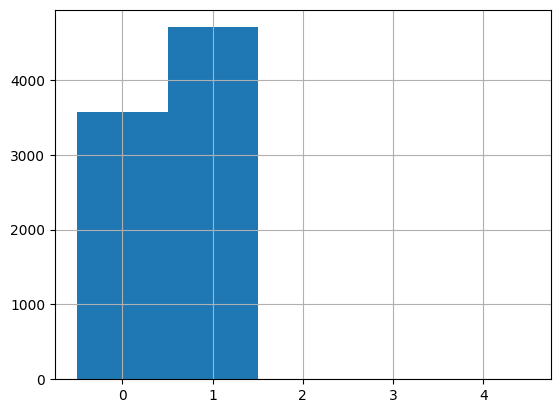

In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


outcomes=(np.unique(train_df['Outcome']))
le.fit(list(set(outcomes)))
y = le.transform( train_df['Outcome'] )



print ("Classes                          : ",(outcomes))
print ("Number of cpds in each class     : ",np.unique([len(y[y==smi]) for smi in y]))
print ("Total number of cpds             : ",len(y))

S =train_df['Outcome']
info = {}
for i,cls in enumerate(S.unique()):
    info.update({cls:i})
    S = S.replace(cls,i)

ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info

In [8]:
train_df = train_df.rename(columns={'labels': 'Outcome'})

In [9]:
x_data = train_df

In [ ]:
x_data = train_df.drop(columns=['smiles', 'Outcome', 'IUPAC name', 'ID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor', 'SMILES', 'Molecular Weight',
       'logP','RowID','ALogP','ALogP2'])
print(x_data)

In [10]:
x_data = train_df.drop(columns=['smiles', 'Outcome', 'IUPAC name', 'ID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor', 'SMILES', 'Molecular Weight',
       'Molecule (RDKit Mol) (InChI Code)','RowID','ALogP','ALogP2'])
print(x_data)

      Molecular weight  nHBDon  nAtomLAC  nAtomLC  PetitjeanNumber  nRotB  \
0              564.618       3        10     41.0              0.5      8   
4479           502.585       2         5     36.0              0.5      8   
4478           520.969       1         6     37.0              0.5      9   
4477           397.479       2         7     29.0              0.5      4   
4475           459.512       1         3     33.0              0.5      4   
...                ...     ...       ...      ...              ...    ...   
1600           505.522       0         7     35.0              0.5      4   
4598           441.265       1         5     28.0              0.5      3   
4597           365.405       1         6     25.0              0.5      2   
1593           414.571       1         4     29.0              0.5      6   
8270           377.916       1         4     26.0              0.5      4   

      LipinskiFailures  TopoPSA   VAdjMat    XLogP      Fsp3      AMW  \
0 

In [11]:
x = x_data

In [12]:
x

,Molecular weight,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,AMW,logP,MLogP,TPSA,AMR,LabuteASA,NumLipinskiHBA,NumHBA,nHBAcc,NumLipinskiHBD,NumHBD,NumRotatableBonds,NumAmideBonds,NumHeteroAtoms,NumAtoms,NumRings,NumAromaticRings,naAromAtom,NumSaturatedRings,NumAliphaticRings,NumAromaticHeterocycles,NumSaturatedHeterocycles,NumAliphaticHeterocycles,NumAromaticCarbocycles,NumSaturatedCarbocycles,NumAliphaticCarbocycles,Chi0v,Chi1v,Chi2v,Chi3v,Chi4v,Chi1n,Chi2n,Chi3n,Chi4n,HallKierAlpha,kappa1,kappa2,kappa3,FractionCSP3,bpol,nB,ECCEN,fragC,nAtomP
0,564.618,3,10,41.0,0.5,8,0.0,142.74,0.997293,2.40390,0.517241,564.618,2.40390,2.40390,142.74,146.1108,235.865709,10,10,10,3,3,8,1,12,41,8,3,3,4,5,3,3,4,0,1,1,22.657823,14.150854,11.551281,8.862189,6.256182,14.150854,11.551281,8.862189,6.256182,-3.45,26.448947,10.429668,5.205552,0.517241,531.354,8,0.0,0.0,41.0
4479,502.585,2,5,36.0,0.5,8,0.0,67.12,1.226226,4.68100,0.461538,502.585,4.68100,4.68100,67.12,131.5904,208.859606,5,5,5,2,2,8,2,10,36,4,3,3,1,1,2,1,1,1,0,0,20.579190,12.267849,9.749864,6.663807,4.451475,12.267849,9.749864,6.663807,4.451475,-3.27,25.811909,11.197221,6.902427,0.461538,469.321,8,0.0,0.0,36.0
4478,520.969,1,6,37.0,0.5,9,0.0,102.10,1.420589,6.27644,0.178571,520.969,6.27644,6.27644,102.10,137.7088,218.578726,6,6,6,1,1,9,1,9,37,4,4,4,0,0,1,0,0,3,0,0,21.066299,11.836135,8.832130,5.693712,3.629533,11.458171,8.395694,5.441736,3.503545,-4.30,25.782786,11.623050,7.112742,0.178571,495.769,9,0.0,0.0,37.0
4477,397.479,2,7,29.0,0.5,4,0.0,100.47,1.640404,2.48210,0.523810,397.479,2.48210,2.48210,100.47,109.5365,169.894081,7,7,7,2,2,4,1,8,29,4,2,2,1,2,2,0,1,0,1,1,17.052200,10.016053,8.202117,5.686320,3.996700,10.016053,8.202117,5.686320,3.996700,-2.58,19.724162,7.682627,3.948972,0.523810,370.263,4,0.0,0.0,29.0
4475,459.512,1,3,33.0,0.5,4,0.0,47.02,1.745216,3.64560,0.400000,459.512,3.64560,3.64560,47.02,120.2038,191.263343,3,3,3,1,1,4,2,8,33,4,2,2,1,2,0,1,2,2,0,0,18.717383,10.971668,8.856023,6.752500,4.868985,10.971668,8.856023,6.752500,4.868985,-2.84,23.322620,9.190471,4.247909,0.400000,431.288,4,0.0,0.0,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1600,505.522,0,7,35.0,0.5,4,0.0,88.40,1.427470,3.20140,0.347826,505.522,3.20140,3.20140,88.40,120.8403,199.448484,7,7,7,0,0,4,1,12,35,5,3,3,1,2,2,1,2,1,0,0,19.603544,12.837746,10.878030,7.393731,5.039756,10.946335,8.862294,6.283493,4.392593,-3.41,23.337407,8.363538,4.617110,0.347826,483.346,4,0.0,0.0,35.0
4598,441.265,1,5,28.0,0.5,3,0.0,53.12,2.034467,6.35838,0.111111,441.265,6.35838,6.35838,53.12,104.0807,170.288740,5,5,5,1,1,3,0,10,28,4,4,4,0,0,3,0,0,1,0,0,16.139274,9.506460,7.733230,5.751016,3.893223,7.870878,5.886584,4.152478,2.932851,-2.47,18.873062,6.849140,3.154790,0.111111,432.193,3,0.0,0.0,28.0
4597,365.405,1,6,25.0,0.5,2,0.0,73.64,1.725003,3.29582,0.411765,365.405,3.29582,3.29582,73.64,90.1564,147.213288,6,6,6,1,1,2,0,8,25,4,2,2,1,2,1,1,2,1,0,0,14.354370,8.936026,7.409150,5.686476,4.513069,7.950427,6.368865,4.730387,3.501873,-1.93,16.533706,6.102288,2.827717,0.411765,348.269,2,0.0,0.0,25.0
1593,414.571,1,4,29.0,0.5,6,0.0,60.85,1.408414,3.13570,0.478261,414.571,3.13570,3.13570,60.85,115.2336,173.565875,4,4,4,1,1,6,0,6,29,4,2,2,2,2,0,2,2,2,0,0,17.813239,11.989787,10.242006,8.163101,5.851146,10.549723,8.304071,6.283736,4.358888,-1.73,20.539054,8.559561,4.557321,0.478261,384.331,6,0.0,0.0,29.0


In [13]:
y

array([0, 0, 0, ..., 1, 1, 1])

In [14]:
#Random Forest
from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier

paramgrid = {
    "max_features": [
        x.shape[1], x.shape[1] // 2, x.shape[1] // 4, x.shape[1] // 12, x.shape[1] // 10,
        x.shape[1] // 7, x.shape[1] // 5, x.shape[1] // 3
    ],
    "n_estimators": [10, 100, 300],
}

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

model_rf_phys = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced'),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1
)

model_rf_phys.fit(x, y)

best_model_rf_phys = model_rf_phys.best_estimator_

print("Best Params:", model_rf_phys.best_params_)
print("Best Score :", model_rf_phys.best_score_)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Params: {'max_features': 4, 'n_estimators': 300}
Best Score : 0.5185930694837083


In [17]:
#Random Forest
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

seed = 42
np.random.seed(seed)

n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

for train_index, test_index in cv.split(x, y):
    # kalau x DataFrame → gunakan iloc
    if hasattr(x, "iloc"):
        X_train, X_test = x.iloc[train_index], x.iloc[test_index]
    else:  # kalau x numpy array
        X_train, X_test = x[train_index], x[test_index]

    if hasattr(y, "iloc"):
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    else:  # kalau y numpy array
        y_train, y_test = y[train_index], y[test_index]

    best_model_rf_phys.fit(X_train, y_train)

    y_pred = best_model_rf_phys.predict(X_test)
    y_proba = best_model_rf_phys.predict_proba(X_test)[:, 1]

    # lanjutkan perhitungan metric seperti sebelumnya...

    
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))  
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[482 232]
 [159 782]]
Confusion Matrix for Fold 2:
[[485 229]
 [181 759]]
Confusion Matrix for Fold 3:
[[505 209]
 [152 788]]
Confusion Matrix for Fold 4:
[[483 230]
 [177 764]]
Confusion Matrix for Fold 5:
[[471 242]
 [137 804]]
Overall CV Accuracy: 0.7644783861882025
Overall CV AUC: 0.8395798851546683
Overall CV Precision: 0.7734094020158401
Overall CV Recall (Sensitivity): 0.8286175865421574
Overall CV F1 Score: 0.7999795991934211
Overall CV Specificity: 0.6799266130014419
Overall CV PPV (Positive Predictive Value): 0.7734094020158401
Overall CV NPV (Negative Predictive Value): 0.7510625796735125
Overall CV CCR (Correct Classification Rate): 0.7542720997717997


In [18]:
#SVM
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

paramgrid = {
    "C": [0.1, 1, 10, 15],
    "kernel": ['rbf'],
    "gamma": ['scale', 'auto']
}

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

model_svm_phys = GridSearchCV(
    estimator=SVC(probability=True),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=1
)

model_svm_phys.fit(x, y)

best_model_svm_phys = model_svm_phys.best_estimator_

print("Best Params:", model_svm_phys.best_params_)
print("Best Score :", model_svm_phys.best_score_)


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'C': 15, 'gamma': 'auto', 'kernel': 'rbf'}
Best Score : 0.2860890950747059


In [19]:
#SVM
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

seed = 42
np.random.seed(seed)

n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

accuracies, auc_scores, precisions, recalls, f1_scores = [], [], [], [], []
specificities, sensitivity_scores, ppvs, npvs, ccrs, confusion_matrices = [], [], [], [], [], []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

for train_index, test_index in cv.split(x, y):
    # indexing: gunakan iloc jika x/y DataFrame, [] jika numpy array
    X_train = x.iloc[train_index] if hasattr(x, "iloc") else x[train_index]
    X_test  = x.iloc[test_index]  if hasattr(x, "iloc") else x[test_index]
    y_train = y.iloc[train_index] if hasattr(y, "iloc") else y[train_index]
    y_test  = y.iloc[test_index]  if hasattr(y, "iloc") else y[test_index]
    
    best_model_svm_phys.fit(X_train, y_train)
    
    y_pred = best_model_svm_phys.predict(X_test)
    y_proba = best_model_svm_phys.predict_proba(X_test)[:, 1]
    
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    ccrs.append(calculate_ccr(sensitivity, specificity))

for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)

print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[351 363]
 [201 740]]
Confusion Matrix for Fold 2:
[[357 357]
 [204 736]]
Confusion Matrix for Fold 3:
[[340 374]
 [185 755]]
Confusion Matrix for Fold 4:
[[357 356]
 [202 739]]
Confusion Matrix for Fold 5:
[[349 364]
 [201 740]]
Overall CV Accuracy: 0.6606216185608814
Overall CV AUC: 0.7208821799142765
Overall CV Precision: 0.6716365347223466
Overall CV Recall (Sensitivity): 0.7888599724150407
Overall CV F1 Score: 0.725518865396708
Overall CV Specificity: 0.4915938886073364
Overall CV PPV (Positive Predictive Value): 0.6716365347223466
Overall CV NPV (Negative Predictive Value): 0.6386076266167267
Overall CV CCR (Correct Classification Rate): 0.6402269305111885


In [20]:
#XGB
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

paramgrid = {
    "max_depth": [3, 5, 7],
    "n_estimators": [100, 200],
    "learning_rate": [0.1, 0.2, 0.4]
}

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

model_xgb_phys = GridSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1
)

model_xgb_phys.fit(x, y)

best_model_xgb_phys = model_xgb_phys.best_estimator_

print("Best Params:", model_xgb_phys.best_params_)
print("Best Score :", model_xgb_phys.best_score_)


Fitting 5 folds for each of 18 candidates, totalling 90 fits


C:\Users\User\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:158: UserWarning: [22:50:59] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}
Best Score : 0.4999233044688598


In [21]:
#XGBOOST
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

seed = 42
np.random.seed(seed)

n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

accuracies, auc_scores, precisions, recalls, f1_scores = [], [], [], [], []
specificities, sensitivity_scores, ppvs, npvs, ccrs, confusion_matrices = [], [], [], [], [], []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

for train_index, test_index in cv.split(x, y):
    # indexing: gunakan iloc jika DataFrame, [] jika numpy array
    X_train = x.iloc[train_index] if hasattr(x, "iloc") else x[train_index]
    X_test  = x.iloc[test_index]  if hasattr(x, "iloc") else x[test_index]
    y_train = y.iloc[train_index] if hasattr(y, "iloc") else y[train_index]
    y_test  = y.iloc[test_index]  if hasattr(y, "iloc") else y[test_index]
    
    best_model_xgb_phys.fit(X_train, y_train)
    
    y_pred = best_model_xgb_phys.predict(X_test)
    y_proba = best_model_xgb_phys.predict_proba(X_test)[:, 1]
    
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    ccrs.append(calculate_ccr(sensitivity, specificity))

for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)

print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


C:\Users\User\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:158: UserWarning: [22:51:00] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\User\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:158: UserWarning: [22:51:01] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\User\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:158: UserWarning: [22:51:02] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, Us

Confusion Matrix for Fold 1:
[[498 216]
 [164 777]]
Confusion Matrix for Fold 2:
[[509 205]
 [212 728]]
Confusion Matrix for Fold 3:
[[507 207]
 [179 761]]
Confusion Matrix for Fold 4:
[[496 217]
 [194 747]]
Confusion Matrix for Fold 5:
[[478 235]
 [155 786]]
Overall CV Accuracy: 0.7601244990629692
Overall CV AUC: 0.832659071688617
Overall CV Precision: 0.7787285598538365
Overall CV Recall (Sensitivity): 0.8077755669613584
Overall CV F1 Score: 0.7928095358812939
Overall CV Specificity: 0.6973014170605129
Overall CV PPV (Positive Predictive Value): 0.7787285598538365
Overall CV NPV (Negative Predictive Value): 0.7342543432610402
Overall CV CCR (Correct Classification Rate): 0.7525384920109357


In [22]:
# NN
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score
import pandas as pd
import numpy as np

# preparing data 
if 'x' not in locals():
    raise ValueError("Variabel 'x' dan 'y' belum didefinisikan!")

if isinstance(x, (pd.DataFrame, pd.Series)):
    X_data = x.to_numpy()
else:
    X_data = x

if isinstance(y, (pd.DataFrame, pd.Series)):
    y_data = y.to_numpy()
else:
    y_data = y

paramgrid_nn = {
    'hidden_layer_sizes': [(100,), (50, 50), (100, 50)], 
    'activation': ['relu'],           
    'alpha': [0.0001, 0.01],          
    'learning_rate_init': [0.001, 0.01] 
}

cv_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

model_nn_phys = GridSearchCV(
    estimator=MLPClassifier(
        solver='adam',          
        max_iter=1000,          
        early_stopping=True,    
        random_state=24
    ),
    param_grid=paramgrid_nn,
    scoring=kappa_scorer,
    cv=cv_split,
    verbose=1,
    n_jobs=-1 
)

model_nn_phys.fit(X_data, y_data)
best_model_nn_phys = model_nn_phys.best_estimator_

print("Best Params:", model_nn_phys.best_params_)
print("Best Score :", model_nn_phys.best_score_)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01}
Best Score : 0.26389967433347034


In [23]:
# NN
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

seed = 42
np.random.seed(seed)
n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

accuracies, auc_scores, precisions, recalls, f1_scores = [], [], [], [], []
specificities, sensitivity_scores, ppvs, npvs, ccrs, confusion_matrices = [], [], [], [], [], []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

for train_index, test_index in cv.split(x, y):
    # indexing: gunakan iloc jika DataFrame, [] jika numpy array
    X_train = x.iloc[train_index] if hasattr(x, "iloc") else x[train_index]
    X_test  = x.iloc[test_index]  if hasattr(x, "iloc") else x[test_index]
    y_train = y.iloc[train_index] if hasattr(y, "iloc") else y[train_index]
    y_test  = y.iloc[test_index]  if hasattr(y, "iloc") else y[test_index]
    
    best_model_nn_phys.fit(X_train, y_train)
    
    y_pred = best_model_nn_phys.predict(X_test)
    y_proba = best_model_nn_phys.predict_proba(X_test)[:, 1]
    
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    ccrs.append(calculate_ccr(sensitivity, specificity))

for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)

print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[334 380]
 [195 746]]
Confusion Matrix for Fold 2:
[[297 417]
 [173 767]]
Confusion Matrix for Fold 3:
[[351 363]
 [225 715]]
Confusion Matrix for Fold 4:
[[372 341]
 [281 660]]
Confusion Matrix for Fold 5:
[[436 277]
 [300 641]]
Overall CV Accuracy: 0.6430891695313383
Overall CV AUC: 0.6915168042695431
Overall CV Precision: 0.6662378605227726
Overall CV Recall (Sensitivity): 0.7503882243878174
Overall CV F1 Score: 0.7043986787597565
Overall CV Specificity: 0.5017179943506155
Overall CV PPV (Positive Predictive Value): 0.6662378605227726
Overall CV NPV (Negative Predictive Value): 0.6069479135016707
Overall CV CCR (Correct Classification Rate): 0.6260531093692164


In [24]:
# LGBM 
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

paramgrid = {
    "n_estimators": [200, 230],
    "learning_rate": [0.05, 0.1, 0.3],
    "max_depth": [1, 10, 15],
    "num_leaves": [31, 50]
}

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

model_lgbm_phys = GridSearchCV(
    estimator=LGBMClassifier(
        objective="binary",
        class_weight="balanced",
        verbosity=-1,
        force_row_wise=True,
        random_state=24
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1
)

model_lgbm_phys.fit(x, y)
best_model_lgbm_phys = model_lgbm_phys.best_estimator_

print("Best Params:", model_lgbm_phys.best_params_)
print("Best Score :", model_lgbm_phys.best_score_)


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Params: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 230, 'num_leaves': 50}
Best Score : 0.5059624401303449


In [25]:
# LGBM
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    precision_score, recall_score, f1_score
)
import numpy as np

seed = 42
np.random.seed(seed)

n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

accuracies, auc_scores, precisions, recalls, f1_scores = [], [], [], [], []
specificities, sensitivity_scores, ppvs, npvs, ccrs, confusion_matrices = [], [], [], [], [], []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

for train_index, test_index in cv.split(x, y):
    # indexing: gunakan iloc jika DataFrame, [] jika numpy array
    X_train = x.iloc[train_index] if hasattr(x, "iloc") else x[train_index]
    X_test  = x.iloc[test_index]  if hasattr(x, "iloc") else x[test_index]
    y_train = y.iloc[train_index] if hasattr(y, "iloc") else y[train_index]
    y_test  = y.iloc[test_index]  if hasattr(y, "iloc") else y[test_index]
    
    best_model_lgbm_phys.fit(X_train, y_train)
    
    y_pred = best_model_lgbm_phys.predict(X_test)
    y_proba = best_model_lgbm_phys.predict_proba(X_test)[:, 1]
    
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    ccrs.append(calculate_ccr(sensitivity, specificity))

for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)

print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[499 215]
 [181 760]]
Confusion Matrix for Fold 2:
[[523 191]
 [238 702]]
Confusion Matrix for Fold 3:
[[523 191]
 [200 740]]
Confusion Matrix for Fold 4:
[[512 201]
 [221 720]]
Confusion Matrix for Fold 5:
[[521 192]
 [185 756]]
Overall CV Accuracy: 0.7563771795555588
Overall CV AUC: 0.8321248543399937
Overall CV Precision: 0.7879345933575352
Overall CV Recall (Sensitivity): 0.7820476179709228
Overall CV F1 Score: 0.7848166375189585
Overall CV Specificity: 0.7225346800711869
Overall CV PPV (Positive Predictive Value): 0.7879345933575352
Overall CV NPV (Negative Predictive Value): 0.7161823256004727
Overall CV CCR (Correct Classification Rate): 0.7522911490210549


In [26]:
import joblib

base_path = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Cardiac toxicity\model\physical chemical properties model"

joblib.dump(
    best_model_rf_phys,
    fr"{base_path}\Model_Cardiac_RF_phys.pkl",
    compress=9
)

joblib.dump(
    best_model_xgb_phys,
    fr"{base_path}\Model_Cardiac_XGB_phys.pkl",
    compress=9
)

joblib.dump(
    best_model_svm_phys,
    fr"{base_path}\Model_Cardiac_SVM_phys.pkl",
    compress=9
)

joblib.dump(
    best_model_nn_phys,
    fr"{base_path}\Model_Cardiac_NN_phys.pkl",
    compress=9
)

joblib.dump(
    best_model_lgbm_phys,
    fr"{base_path}\Model_Cardiac_LGBM_phys.pkl",
    compress=9
)


['C:\\Users\\User\\Documents\\KULIAH TELKOM S1\\SKRIPSI\\UJI COBA QSAR - PRIBADI\\Cardiac toxicity\\model\\physical chemical properties model\\Model_Cardiac_LGBM_phys.pkl']